# 26.08.31 수업

In [30]:
# !pip install tfswin

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tfswin import SwinTransformerTiny224, preprocess_input
import matplotlib.pyplot as plt


In [32]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar100.load_data()

In [33]:
inputs = layers.Input(shape=(32,32,3), dtype="uint8")
outputs = layers.Lambda(preprocess_input)(inputs)
outputs = SwinTransformerTiny224(include_top=False)(outputs)
outputs = layers.Dense(100, activation="softmax")(outputs)

swin = models.Model(inputs=inputs, outputs=outputs)

In [34]:
optimizer = tf.keras.optimizers.Adam()

swin.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseTopKCategoricalAccuracy(1, name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy")
    ]
)

In [35]:
history = swin.fit(x = train_x, y = train_y, batch_size = 128, epochs = 10,
validation_split = 0.2)

Epoch 1/10

313/313 [==============================] - 166s 492ms/step - loss: 3.3553 - accuracy: 0.1893 - top-5-accuracy: 0.4429 - val_loss: 2.4284 - val_accuracy: 0.3543 - val_top-5-accuracy: 0.6962
Epoch 2/10
313/313 [==============================] - 129s 412ms/step - loss: 2.0179 - accuracy: 0.4485 - top-5-accuracy: 0.7766 - val_loss: 1.8908 - val_accuracy: 0.4801 - val_top-5-accuracy: 0.7974
Epoch 3/10
313/313 [==============================] - 125s 398ms/step - loss: 1.5359 - accuracy: 0.5604 - top-5-accuracy: 0.8619 - val_loss: 1.7985 - val_accuracy: 0.5048 - val_top-5-accuracy: 0.8142
Epoch 4/10
313/313 [==============================] - 124s 395ms/step - loss: 1.2062 - accuracy: 0.6429 - top-5-accuracy: 0.9128 - val_loss: 1.7378 - val_accuracy: 0.5331 - val_top-5-accuracy: 0.8343
Epoch 5/10
313/313 [==============================] - 124s 396ms/step - loss: 0.9281 - accuracy: 0.7157 - top-5-accuracy: 0.9477 - val_loss: 1.7815 - val_accuracy: 0.5382 - val_top-5-accuracy: 0.8332

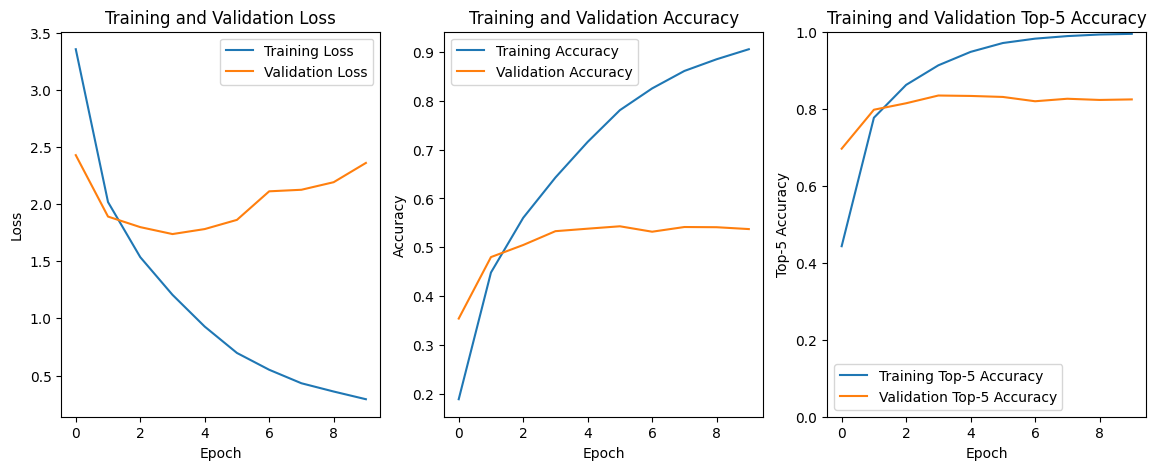

In [36]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['top-5-accuracy'], label='Training Top-5 Accuracy')
plt.plot(history.history['val_top-5-accuracy'], label='Validation Top-5 Accuracy')
plt.title('Training and Validation Top-5 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Top-5 Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [37]:
swin.evaluate(test_x, test_y)

313/313 [==============================] - 21s 67ms/step - loss: 2.3505 - accuracy: 0.5457 - top-5-accuracy: 0.8232


[2.3504884243011475, 0.5457000136375427, 0.823199987411499]